[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/02_data_science/A3_forecasting_deep_learning.ipynb)

> 📎 **Appendix notebook — reference style.** This is one of the optional appendices (see `README.md`). Unlike the main course notebooks, appendices are written as a demo / reference: they focus on *seeing* a library at work rather than on interactive exercises. You won't find the full Solution / Debug-me / Self-assessment scaffolding here. Each appendix is built to run end-to-end *without* the optional library — it falls back to a small built-in stand-in (or skips the library-specific cells), so you can read and run it offline. Install the optional library (see the **Install** section below) to swap the stand-in for the real thing.

---
# 📓 Notebook A3 (DS) — Deep-Learning Forecasting (LSTM, Transformer)

> **Module:** Data Science · **Type:** Appendix · **Estimated time:** 75–90 min · **Difficulty:** Advanced

Classical forecasting (A1) excels at small, well-behaved series. Modern libraries (A2) make things convenient. But when you have **lots of related series**, **rich covariates**, or **long horizons with strong non-linearities**, deep-learning forecasters genuinely move the needle.

This notebook implements two from-scratch PyTorch forecasters on the same demand-flavoured series, then introduces the production-grade alternatives (N-BEATS, N-HiTS, TFT).

---

## ✅ Prerequisites
- Notebook 11 (forecasting basics) + Notebook A1 (classical).
- Notebooks A1–A2 of the **ML appendix** (PyTorch foundations + sequences).

## 📦 Install

```bash
pip install torch                              # CPU build for laptops
# Optional production libraries:
pip install darts                              # bundles N-BEATS, N-HiTS, TFT
pip install pytorch-forecasting                # TFT, DeepAR, etc.
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import TensorDataset, DataLoader
    HAS_TORCH = True
    torch.manual_seed(0)
    print(f"PyTorch {torch.__version__}")
except Exception as e:
    HAS_TORCH = False
    print("PyTorch not installed —", e)

from sklearn.metrics import mean_absolute_error


PyTorch 2.12.0


## 1. The dataset — daily product searches (same as A1/A2)


In [2]:
rng = np.random.default_rng(0)
n = 540
dates = pd.date_range("2024-01-01", periods=n, freq="D")
trend  = 0.04 * np.arange(n)
weekly = 8 * np.sin(2 * np.pi * np.arange(n) / 7) + 4 * np.cos(2 * np.pi * np.arange(n) / 7)
yearly = 6 * np.sin(2 * np.pi * np.arange(n) / 365)
promo  = np.where((np.arange(n) > 200) & (np.arange(n) < 220), 12, 0)
noise  = rng.normal(0, 2.5, size=n)
y      = 50 + trend + weekly + yearly + promo + noise

ts = pd.Series(y, index=dates, name="searches")
train_v = ts[:-30].values; test_v = ts[-30:].values
print(f"train {len(train_v)}  test {len(test_v)}")


train 510  test 30


## 2. Reshape for sequence learning

For supervised forecasting we slice the series into **(input window → forecast window)** pairs.


In [3]:
def make_windows(series, input_len, output_len):
    X, y = [], []
    for i in range(len(series) - input_len - output_len + 1):
        X.append(series[i:i+input_len])
        y.append(series[i+input_len:i+input_len+output_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

INPUT_LEN, OUTPUT_LEN = 28, 14

# Normalise using train stats only
mu, sd = train_v.mean(), train_v.std()
norm   = (ts.values - mu) / sd

X_all, y_all = make_windows(norm, INPUT_LEN, OUTPUT_LEN)
print("window shape:", X_all.shape, y_all.shape)

# Hold out the last test windows
n_test = 30
X_tr, X_te = X_all[:-n_test], X_all[-n_test:]
y_tr, y_te = y_all[:-n_test], y_all[-n_test:]
print(f"train windows {X_tr.shape}  test windows {X_te.shape}")


window shape: (499, 28) (499, 14)
train windows (469, 28)  test windows (30, 28)


### 🔬 What actually happens when you "window" a time series?

A raw time series is just a flat row of numbers in time order:

```text
series:  10  12  13  15  14  17  19  ...
index:    0   1   2   3   4   5   6
```

But an LSTM / Transformer can't eat a flat row. These models expect **sequences of fixed length**: "here are the last `window_size` steps — now predict what comes next." So before any model runs, you must **manufacture training samples** out of the raw series. That manufacturing step is *windowing*, and it's exactly what `make_windows` above is doing.

The idea is a **sliding window**. Pick a window size (say 3). Lay it over the start of the series; the values under the window become one input `X`, and the value (or values) right after it become the target `y`. Then **slide the window one step to the right** and repeat. Each slide produces one more `(X → y)` training sample, and because consecutive windows overlap by all-but-one step, a short series yields *many* samples.

```text
window_size = 3, predict the NEXT 1 value

series:  10  12  13  15  14  17  19

slide 0: [10 12 13] 15            ->  X=[10,12,13]   y=15
slide 1:    [12 13 15] 14         ->  X=[12,13,15]   y=14
slide 2:       [13 15 14] 17      ->  X=[13,15,14]   y=17
slide 3:          [15 14 17] 19   ->  X=[15,14,17]   y=19
          └── input window ──┘ └ target (next step)
```

Notice the overlap: row 1's input `[12 13 15]` is row 0's input shifted left by one, with one new value appended. Sliding by one is what produces all those overlapping rows from a single series.


### The shape: `(n_samples, timesteps, n_features)`

Stack all those `X` rows on top of each other and you get a 2-D table — `n_samples` rows, each `window_size` long. Sequence models actually want a **3-D** tensor, because each timestep can carry several features (here just 1: the value itself). So the canonical input shape is:

```text
(n_samples, timesteps, n_features)
     │           │           │
     │           │           └─ how many numbers describe ONE timestep
     │           │              (1 for a univariate series; more with covariates)
     │           └───────────── window_size: how far back the model looks
     └───────────────────────── how many windows we sliced out of the series
```

| Term | In this notebook | Meaning |
|---|---|---|
| `n_samples` | `len(series) - input_len - output_len + 1` | number of windows you can slide out |
| `timesteps` | `INPUT_LEN` (28) | how many past steps each window holds |
| `n_features` | 1 | values per step (univariate searches) |
| target | `OUTPUT_LEN` (14) | how many future steps each `y` holds |

A univariate series gives `X` of shape `(n_samples, timesteps)`; you add the trailing feature axis with `X[..., None]` to reach `(n_samples, timesteps, 1)` right before feeding the model.

> 🎯 **Mental model:** *a sequence model predicts the next step(s) from a window of recent steps. You manufacture training data by sliding that window across the series — final input shape `(samples, timesteps, features)`.*


### 🧪 Proof — build the windows by hand and watch them slide

The cell below is fully self-contained (numpy only). It builds a **tiny inline series**, slides a window of size 3 over it, and **prints the first windows** so you can literally see the one-step overlap and confirm the shape.


In [ ]:
import numpy as np

# Tiny, hand-checkable series (no randomness — every number is visible)
series = np.array([10, 12, 13, 15, 14, 17, 19, 18, 21], dtype=np.float32)
print("raw series:", series, " length:", len(series))

def make_windows_demo(series, window, horizon=1):
    """Slide a `window`-long window; target is the next `horizon` step(s)."""
    X_demo, y_demo = [], []
    for i in range(len(series) - window - horizon + 1):
        X_demo.append(series[i : i + window])               # the input window
        y_demo.append(series[i + window : i + window + horizon])  # the next step(s)
    return np.array(X_demo, dtype=np.float32), np.array(y_demo, dtype=np.float32)

WINDOW = 3
X_demo, y_demo = make_windows_demo(series, window=WINDOW, horizon=1)

print("\nFirst windows produced by sliding (one step at a time):")
for i in range(len(X_demo)):
    print(f"  slide {i}:  X = {X_demo[i].tolist()}   ->   y = {y_demo[i].tolist()}")

print("\nX shape:", X_demo.shape, " (n_samples, timesteps)")
print("y shape:", y_demo.shape, " (n_samples, horizon)")

# Sequence models want a trailing feature axis: (n_samples, timesteps, n_features)
X3_demo = X_demo[..., None]
print("X3 shape:", X3_demo.shape, " (n_samples, timesteps, n_features)  <- the model-ready shape")

# Proof of the overlap: window i+1 is window i shifted left by one, plus one new value.
print("\nOverlap check (row 1 == row 0 shifted left + 1 new value):")
print("  row 0:", X_demo[0].tolist())
print("  row 1:", X_demo[1].tolist(), " <- last 2 of row 0 reused, 1 new value appended")
assert X_demo[1][:-1].tolist() == X_demo[0][1:].tolist()
print("  assert passed: consecutive windows overlap by (window-1) steps")


### One-step vs multi-step targets

The `horizon` argument controls **how far ahead** each sample predicts:

- **One-step** (`horizon=1`): each window predicts a single next value. To forecast further you feed the prediction back in and slide again (autoregressive roll-out).
- **Multi-step** (`horizon=k`): each window predicts the next `k` values *at once* (this is what Section 2 does with `OUTPUT_LEN=14` — a 14-day forecast in one shot). The target `y` then has shape `(n_samples, k)`.

```text
one-step  (horizon=1):   [.. .. ..] -> [next]
multi-step(horizon=3):   [.. .. ..] -> [next, next+1, next+2]
```

> ⚠️ **Do NOT shuffle across the time boundary when splitting.** Windowing creates overlapping samples, so a naive random shuffle would put windows that *contain future days* into the training set and windows from the *past* into the test set — the model would peek at the future (leakage) and your test score would be a fantasy. Always split **chronologically**: earliest windows train, latest windows test (that's why Section 2 slices `X_all[:-n_test]` / `X_all[-n_test:]` instead of `train_test_split(shuffle=True)`). **NB 11** builds the proper rolling/expanding-window evaluation for time series (the walk-forward backtest).

> 🧠 **Recap:** windowing = slide a fixed window across the series, one step at a time, to turn a flat sequence into many `(window → next)` supervised samples of shape `(samples, timesteps, features)` — never shuffling across time.


## 3. LSTM forecaster

Single-layer LSTM that consumes the input window and produces a multi-step forecast as a vector.


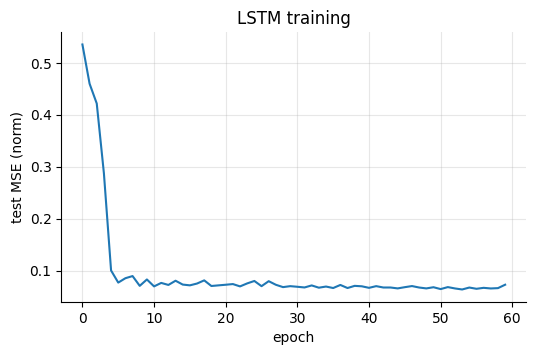

In [4]:
if HAS_TORCH:
    class LSTMForecaster(nn.Module):
        def __init__(self, hidden=64, output_len=OUTPUT_LEN):
            super().__init__()
            self.lstm = nn.LSTM(1, hidden, batch_first=True, num_layers=1)
            self.head = nn.Linear(hidden, output_len)
        def forward(self, x):     # x: (B, L)
            x = x.unsqueeze(-1)   # (B, L, 1)
            out, (h, _) = self.lstm(x)
            return self.head(h.squeeze(0))    # (B, output_len)

    Xt_tr = torch.from_numpy(X_tr); yt_tr = torch.from_numpy(y_tr)
    Xt_te = torch.from_numpy(X_te); yt_te = torch.from_numpy(y_te)
    dl    = DataLoader(TensorDataset(Xt_tr, yt_tr), batch_size=32, shuffle=True)

    lstm = LSTMForecaster()
    opt  = torch.optim.Adam(lstm.parameters(), lr=3e-3)
    loss_fn = nn.MSELoss()

    history = []
    for epoch in range(60):
        lstm.train()
        for xb, yb in dl:
            opt.zero_grad(); loss = loss_fn(lstm(xb), yb); loss.backward(); opt.step()
        lstm.eval()
        with torch.no_grad():
            val = loss_fn(lstm(Xt_te), yt_te).item()
        history.append((epoch, val))

    plt.figure(figsize=(6, 3.5))
    plt.plot(*zip(*history)); plt.xlabel("epoch"); plt.ylabel("test MSE (norm)")
    plt.title("LSTM training"); plt.show()


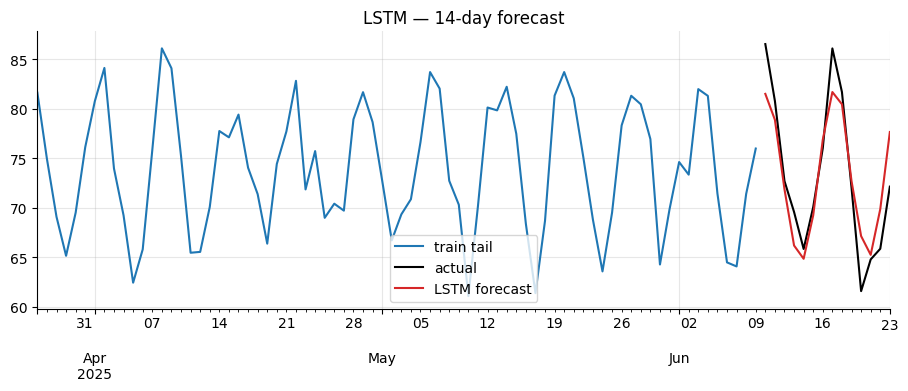

LSTM  MAE  = 8.79


In [5]:
if HAS_TORCH:
    # Re-forecast the held-out tail
    last_window = torch.from_numpy(norm[-(INPUT_LEN+OUTPUT_LEN):-OUTPUT_LEN]).float().unsqueeze(0)
    lstm.eval()
    with torch.no_grad():
        pred = lstm(last_window).squeeze().numpy() * sd + mu

    fig, ax = plt.subplots(figsize=(11, 3.6))
    ts[-90:-OUTPUT_LEN].plot(ax=ax, label="train tail")
    ts[-OUTPUT_LEN:].plot(ax=ax, label="actual", color="black")
    pd.Series(pred, index=ts.index[-OUTPUT_LEN:]).plot(ax=ax, label="LSTM forecast", color="C3")
    ax.legend(); ax.set_title("LSTM — 14-day forecast"); plt.show()
    print(f"LSTM  MAE  = {mean_absolute_error(test_v[:OUTPUT_LEN], pred):.2f}")


## 4. Transformer-encoder forecaster

The same architecture as `A2_pytorch_vision_and_sequences.ipynb`, adapted for forecasting:
- Input: `(B, L)` time series.
- Positional encoding.
- Transformer encoder (2 layers, 4 heads).
- Output head produces `(B, output_len)` — multi-step at once (a.k.a. "direct" forecasting).


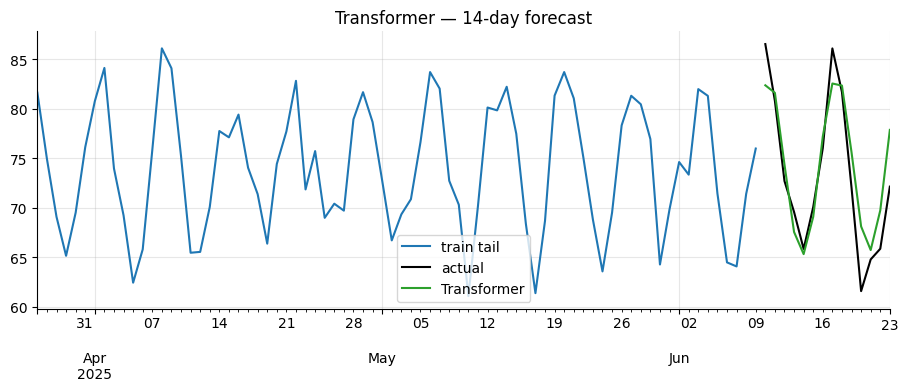

Transformer  MAE = 8.64


In [6]:
if HAS_TORCH:
    class TransformerForecaster(nn.Module):
        def __init__(self, d_model=32, n_heads=4, n_layers=2, output_len=OUTPUT_LEN, max_len=200):
            super().__init__()
            self.proj = nn.Linear(1, d_model)
            pe = torch.zeros(max_len, d_model)
            position = torch.arange(0, max_len).unsqueeze(1)
            div = torch.exp(torch.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
            pe[:, 0::2] = torch.sin(position * div); pe[:, 1::2] = torch.cos(position * div)
            self.register_buffer("pe", pe)
            layer    = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=64,
                                                  dropout=0.1, batch_first=True)
            self.enc = nn.TransformerEncoder(layer, num_layers=n_layers)
            self.head = nn.Linear(d_model, output_len)
        def forward(self, x):                                 # (B, L)
            x = self.proj(x.unsqueeze(-1)) + self.pe[: x.size(1)]
            x = self.enc(x)
            return self.head(x.mean(dim=1))                  # mean-pool, then project

    tx = TransformerForecaster()
    opt = torch.optim.Adam(tx.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    for epoch in range(60):
        tx.train()
        for xb, yb in dl:
            opt.zero_grad(); loss_fn(tx(xb), yb).backward(); opt.step()
    tx.eval()
    with torch.no_grad():
        pred_tx = tx(last_window).squeeze().numpy() * sd + mu

    fig, ax = plt.subplots(figsize=(11, 3.6))
    ts[-90:-OUTPUT_LEN].plot(ax=ax, label="train tail")
    ts[-OUTPUT_LEN:].plot(ax=ax, label="actual", color="black")
    pd.Series(pred_tx, index=ts.index[-OUTPUT_LEN:]).plot(ax=ax, label="Transformer", color="C2")
    ax.legend(); ax.set_title("Transformer — 14-day forecast"); plt.show()
    print(f"Transformer  MAE = {mean_absolute_error(test_v[:OUTPUT_LEN], pred_tx):.2f}")


## 5. When to reach for which

| Approach | Strengths | Weaknesses |
|---|---|---|
| **LSTM** | Strong inductive bias for sequential data; few parameters | Slow to train on long sequences; harder to parallelise |
| **Transformer** | Parallelises beautifully on GPU; captures long-range deps | Needs more data; positional encoding decisions matter |
| **N-BEATS / N-HiTS** | Pure MLP backbones with strong inductive bias for forecasting; SOTA on many benchmarks | Less interpretable than ARIMA/Prophet |
| **TFT** (Temporal Fusion Transformer) | Multi-horizon + covariates + quantile loss + interpretable attention | Heaviest model in the menu |
| **DeepAR** | Native probabilistic forecasting | Per-series scaling can bite you |

**Heuristic.** Start with the simplest model that works. Many tabular-feature ML pipelines (lag features → LightGBM) beat fancy DL on small datasets. Reach for DL when you have **multiple series**, **future covariates**, or **non-stationary regimes**.


## 6. Production-grade libraries (reference code)

For real projects you generally don't write the training loop yourself. The two leaders:

```python
# pip install u8darts
# from darts import TimeSeries
# from darts.models import NBEATSModel, TFTModel
#
# series = TimeSeries.from_series(ts)
# nb = NBEATSModel(input_chunk_length=28, output_chunk_length=14, n_epochs=30, random_state=0)
# nb.fit(series[:-30]); fc = nb.predict(30)
#
# tft = TFTModel(input_chunk_length=28, output_chunk_length=14, n_epochs=30,
#                add_relative_index=True, random_state=0)
# tft.fit(series[:-30]); fc_tft = tft.predict(30)
```

```python
# pip install pytorch-forecasting
# from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
# # ... full TFT recipe — see https://pytorch-forecasting.readthedocs.io
```

Both libraries handle:
- Quantile loss + prediction intervals.
- Future covariates (`known_future` columns).
- Multi-series training (one model across many SKUs).
- Validation + checkpointing + logging out of the box.


## 🧪 Exercises

### Exercise 1 — Train on multiple related series
Make 4 related series (`base + small per-series shifts`) and re-train the LSTM on all of them concatenated. Does the test MAE on the original series improve? Multi-series training is exactly how production demand-forecast models work.


In [7]:
if HAS_TORCH:
    # ── Exercise 1 solution ──────────────────────────────────────────────
    series_list = []
    for shift in [0.0, 1.5, -0.7, 0.4]:
        sn = (y + shift * yearly + shift * weekly).astype("float32")
        sn = (sn - mu) / sd
        series_list.append(sn)
    Xs, ys = [], []
    for s in series_list:
        x_, y_ = make_windows(s, INPUT_LEN, OUTPUT_LEN)
        Xs.append(x_); ys.append(y_)
    Xm = np.concatenate(Xs); ym = np.concatenate(ys)
    print("multi-series windows:", Xm.shape)

    Xt = torch.from_numpy(Xm); yt = torch.from_numpy(ym)
    dlm = DataLoader(TensorDataset(Xt, yt), batch_size=64, shuffle=True)
    lstm_m = LSTMForecaster()
    opt = torch.optim.Adam(lstm_m.parameters(), lr=3e-3); loss_fn = nn.MSELoss()
    for epoch in range(40):
        lstm_m.train()
        for xb, yb in dlm:
            opt.zero_grad(); loss_fn(lstm_m(xb), yb).backward(); opt.step()
    lstm_m.eval()
    with torch.no_grad():
        pred_m = lstm_m(last_window).squeeze().numpy() * sd + mu
    print(f"Multi-series LSTM  MAE = {mean_absolute_error(test_v[:OUTPUT_LEN], pred_m):.2f}")


multi-series windows: (1996, 28)


Multi-series LSTM  MAE = 9.33


### Exercise 2 — Probabilistic forecast via MC dropout
Enable dropout at *inference* time. Draw 50 samples per test point and produce empirical 80% intervals. Compare width vs SARIMA's analytic intervals from A1.


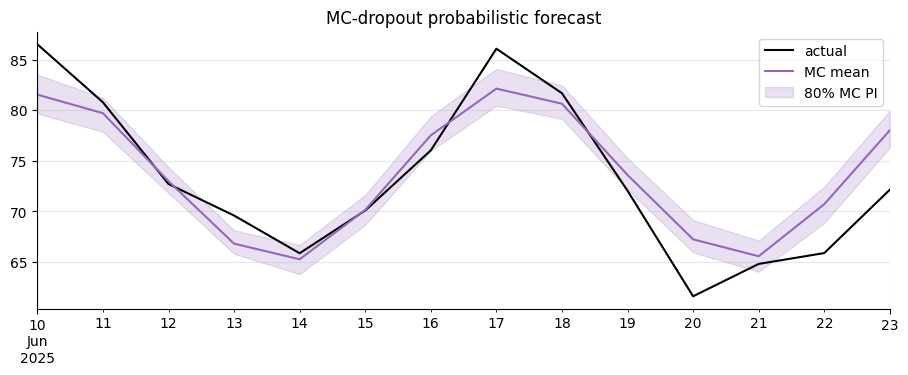

average 80% interval width: 3.21


In [8]:
if HAS_TORCH:
    # ── Exercise 2 solution ──────────────────────────────────────────────
    class DropLSTM(LSTMForecaster):
        def __init__(self):
            super().__init__()
            self.drop = nn.Dropout(0.2)
        def forward(self, x):
            x = x.unsqueeze(-1)
            out, (h, _) = self.lstm(x)
            h = self.drop(h.squeeze(0))
            return self.head(h)

    m = DropLSTM(); opt = torch.optim.Adam(m.parameters(), lr=3e-3); loss_fn = nn.MSELoss()
    for epoch in range(40):
        m.train()
        for xb, yb in dl:
            opt.zero_grad(); loss_fn(m(xb), yb).backward(); opt.step()

    m.train()   # KEEP dropout active for MC sampling
    samples = []
    for _ in range(50):
        with torch.no_grad():
            samples.append(m(last_window).squeeze().numpy() * sd + mu)
    samples = np.stack(samples)
    lo = np.quantile(samples, 0.1, axis=0)
    hi = np.quantile(samples, 0.9, axis=0)
    mean_pred = samples.mean(axis=0)

    fig, ax = plt.subplots(figsize=(11, 3.6))
    ts[-OUTPUT_LEN:].plot(ax=ax, color="black", label="actual")
    idx = ts.index[-OUTPUT_LEN:]
    pd.Series(mean_pred, index=idx).plot(ax=ax, label="MC mean", color="C4")
    ax.fill_between(idx, lo, hi, color="C4", alpha=0.2, label="80% MC PI")
    ax.legend(); ax.set_title("MC-dropout probabilistic forecast"); plt.show()
    print(f"average 80% interval width: {(hi - lo).mean():.2f}")


## 🧠 Key takeaways

- DL forecasters shine when you have **many related series**, **rich covariates**, or **long horizons**.
- The training loop is identical to any other supervised DL: window → batch → backprop.
- Production teams usually use **Darts** or **pytorch-forecasting** rather than from-scratch code.
- **MC dropout** is the cheapest path to a probabilistic interval; quantile loss is the principled one.

## 🚀 Next step

[`A4_forecasting_foundation_models.ipynb`](./A4_forecasting_foundation_models.ipynb) — TimesFM, Chronos, TabPFN-TS: zero-shot foundation models for time series.
